# Douyin Pop Mart Comments Analysis: Identifying Flat Design Style Keywords

This notebook analyzes user comments from Douyin regarding Pop Mart products. The goal is to clean the text data, perform sentiment analysis to focus on positive feedback, and then extract key adjectives to identify prevalent flat design style keywords.



### 1. Data Loading

This section loads the raw user comments from an Excel file into a pandas DataFrame. The `df.head()` function is used to display the first few rows, providing an initial glimpse into the dataset structure and content.

In [34]:
# Import the pandas library for data manipulation
import pandas as pd

# Load the Excel file into a pandas DataFrame
df = pd.read_excel('/content/douyin_popmart_comments.xlsx')

# Display the first few rows of the DataFrame to inspect the data
df.head()

,Comment,Username
0,太可爱了,周柏秀
1,这种不完美风格很涂鸦感，看起来很有倔强。,羲霖
2,心动啦！,春儿
3,这个漫画风 配色大胆真的很有反叛童真，感觉特别倔强。,英君笑傻
4,丹丹说觉得和Zsiga更像是朋友,珠圆玉润苏女士


### 2. Install Required Libraries

Before proceeding with natural language processing and visualization, we need to install the necessary Python libraries:
- `snownlp`: For Chinese sentiment analysis.
- `wordcloud`: To generate visual representations of word frequency.
- `jieba`: A Chinese text segmentation library essential for processing Chinese comments.


In [33]:
# Install necessary libraries for natural language processing and visualization
# snownlp for Chinese sentiment analysis
# wordcloud for generating word clouds
# jieba for Chinese text segmentation
!pip install snownlp wordcloud jieba

In [40]:
# Import regular expression module for text cleaning
import re
# Import jieba's part-of-speech tagging module for Chinese text
import jieba.posseg as pseg
# Import matplotlib for plotting
import matplotlib.pyplot as plt
# Import os module for interacting with the operating system (e.g., checking file existence)
import os
# Import seaborn for enhanced data visualizations
import seaborn as sns
# Import matplotlib's font manager for handling fonts
import matplotlib.font_manager as fm

In [41]:
# Define a function to clean text comments
def clean_text(text):
    # Ensure the input is a string; otherwise, return as is
    if not isinstance(text, str):
        return text
    # Convert text to lowercase for consistency
    text = text.lower()
    # Remove characters that are not Chinese, English letters, or spaces
    text = re.sub(r'[^一-龥a-zA-Z\s]', '', text)
    # Replace multiple spaces with a single space and strip leading/trailing spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply the cleaning function to the 'Comment' column of the DataFrame
df['Comment'] = df['Comment'].apply(clean_text)

print("Starting to remove blank and duplicate comments...")

# Record the initial number of rows before removing blank comments
original_rows = df.shape[0]
# Remove rows where the 'Comment' column is blank (NaN after cleaning)
df.dropna(subset=['Comment'], inplace=True)
# Print the number of rows removed due to blank comments
print(f"Removed {original_rows - df.shape[0]} rows with blank comments.")

# Record the number of rows after removing blank comments
original_rows_after_dropna = df.shape[0]
# Remove duplicate rows based on 'Comment' and 'Username' to avoid bias
df.drop_duplicates(subset=['Comment', 'Username'], inplace=True)
# Print the number of rows removed due to duplication
print(f"Removed {original_rows_after_dropna - df.shape[0]} duplicate rows.")

print("First 5 rows of 'Comment' column after cleaning and filtering:")
# Display the first 20 entries of the cleaned 'Comment' column
df['Comment'].head(20)

Starting to remove blank and duplicate comments...
Removed 0 rows with blank comments.
Removed 0 duplicate rows.
First 5 rows of 'Comment' column after cleaning and filtering:


,Comment
0,太可爱了
1,这种不完美风格很涂鸦感看起来很有倔强
2,心动啦
3,这个漫画风 配色大胆真的很有反叛童真感觉特别倔强
4,丹丹说觉得和zsiga更像是朋友
5,好有爱啊能够感觉到希望人与自然和世界相融合的赶脚
6,每一只都好好看呀
7,好内敛的设计师但是才华横溢的发光很喜欢新娃娃
8,啊啊啊啊啊啊啊终于出了
9,漫画风这种设计真的很有生命力比普通风格更自由


### 3. Data Cleaning and Sentiment Filtering

This crucial step involves several data preparation stages:

1.  **Text Cleaning (`clean_text` function):** Comments are converted to lowercase, punctuation is removed, and extra spaces are stripped. This standardizes the text for better analysis.
2.  **Removal of Blank Comments:** Rows where the 'Comment' column becomes empty after cleaning are removed, ensuring all entries contain meaningful text.
3.  **Removal of Duplicate Comments:** Duplicate entries based on a combination of 'Comment' and 'Username' are dropped to avoid bias from repeated feedback.
4.  **Sentiment Analysis (`get_sentiment_score` function with `SnowNLP`):** Each cleaned comment is analyzed to determine its sentiment score. Comments with sentiment scores below 0.35 are filtered out, focusing specifically on neutral to positive feedback for keyword extraction. This allows us to understand what users appreciate rather than what they dislike.

The output shows the number of rows removed at each stage and the first few rows of the DataFrame after all cleaning and filtering steps are applied.

In [42]:
# Import SnowNLP for Chinese sentiment analysis
from snownlp import SnowNLP

# Define a function to calculate sentiment score using SnowNLP
def get_sentiment_score(text):
    # Ensure the input is a string
    if isinstance(text, str):
        # If the string is empty or only whitespace, return None
        if not text.strip():
            return None
        # Initialize SnowNLP with the text and return its sentiment score
        s = SnowNLP(text)
        return s.sentiments
    # If not a string, return None
    return None

# Apply the sentiment analysis function to the 'Comment' column and store scores in a new column
df['sentiment_score'] = df['Comment'].apply(get_sentiment_score)

# Filter the DataFrame to keep only comments with a sentiment score >= 0.35 (neutral to positive)
df = df[df['sentiment_score'].notna() & (df['sentiment_score'] >= 0.35)]

print("First 5 rows of DataFrame after calculating and filtering sentiment scores:")
# Display the first few rows of the filtered DataFrame
print(df.head())
# Print the shape of the DataFrame after filtering
print(f"\nDataFrame shape after filtering: {df.shape}")

First 5 rows of DataFrame after calculating and filtering sentiment scores:
                    Comment Username  sentiment_score
0                      太可爱了      周柏秀         0.666346
1        这种不完美风格很涂鸦感看起来很有倔强       羲霖         0.956616
2                       心动啦       春儿         0.809524
3  这个漫画风 配色大胆真的很有反叛童真感觉特别倔强     英君笑傻         0.970994
4          丹丹说觉得和zsiga更像是朋友  珠圆玉润苏女士         0.522658

DataFrame shape after filtering: (1823, 3)


### Word Cloud of Comments

To understand the most frequently used words in the comments, let's generate a word cloud. Since the comments are in Chinese, we'll use `jieba` for word segmentation.

Chinese font 'fonts-wqy-zenhei' already installed.


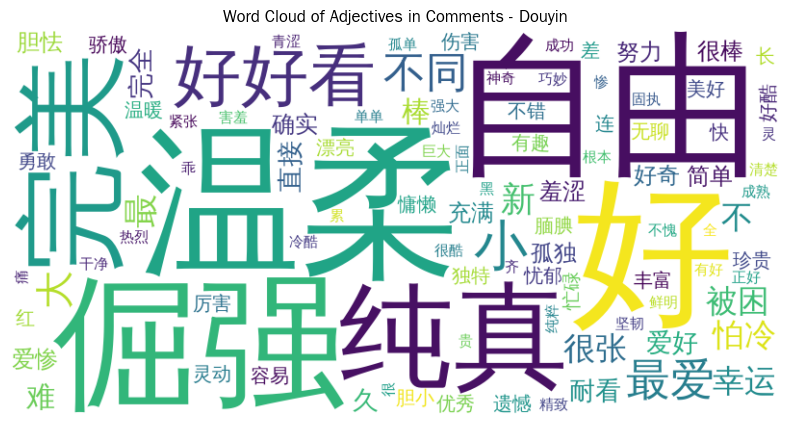

In [43]:
# Import WordCloud for generating word cloud visualizations
from wordcloud import WordCloud

# Define the path to the Chinese font file
font_path = '/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc'

# Check if the Chinese font exists, if not, attempt to install it
if not os.path.exists(font_path):
    print("Installing Chinese font 'fonts-wqy-zenhei'...")
    try:
        # Install the font using apt-get (for Debian-based systems like Colab)
        !apt-get -qq install -y fonts-wqy-zenhei
        print("Chinese font installed successfully.")
    except Exception as e:
        print(f"Error installing font: {e}")
        print("Falling back to a default font (Chinese characters may not display correctly).")
        # Set font_path to None if installation fails to prevent errors later
        font_path = None
else:
    print("Chinese font 'fonts-wqy-zenhei' already installed.")

# Concatenate all comments into a single string for word segmentation
all_comments = ' '.join(df['Comment'].astype(str))

# Perform Chinese word segmentation and part-of-speech tagging using jieba
words_with_pos = pseg.cut(all_comments)

# Extract only adjectives ('a' tag) from the segmented words
adjectives = [word for word, flag in words_with_pos if 'a' in flag]
# Join the extracted adjectives into a single string
filtered_comments = ' '.join(adjectives)

# Generate and display the word cloud if a valid font path is available
if font_path and os.path.exists(font_path):
    # Create a WordCloud object with specified dimensions, background, font, and max words
    wordcloud = WordCloud(width=800, height=400, background_color='white', font_path=font_path, max_words=100).generate(filtered_comments)

    # Plot the generated word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off') # Hide axes
    plt.title('Word Cloud of Adjectives in Comments - Douyin')
    plt.show()
else:
    # Inform the user if the word cloud cannot be generated due to font issues
    print("Word cloud cannot be generated due to missing or invalid font.")

### 4. Word Cloud of Adjectives

To visually identify the most frequently used descriptive words, a word cloud is generated.

-   **Jieba Segmentation:** The `jieba.posseg` library is used to perform part-of-speech tagging on the Chinese comments, allowing us to specifically extract adjectives (words describing qualities or characteristics).
-   **Adjective Filtering:** Only adjectives are selected to ensure that the word cloud highlights descriptive terms relevant to design styles.
-   **Visualization:** The `WordCloud` library creates a visual representation where the size of each word corresponds to its frequency, making it easy to spot the most prominent adjectives. A Chinese font is installed and configured to ensure proper display of characters.

The word cloud provides an intuitive overview of the most emphasized characteristics mentioned by users in their positive feedback.

Chinese font 'wqy-zenhei.ttc' configured for matplotlib.


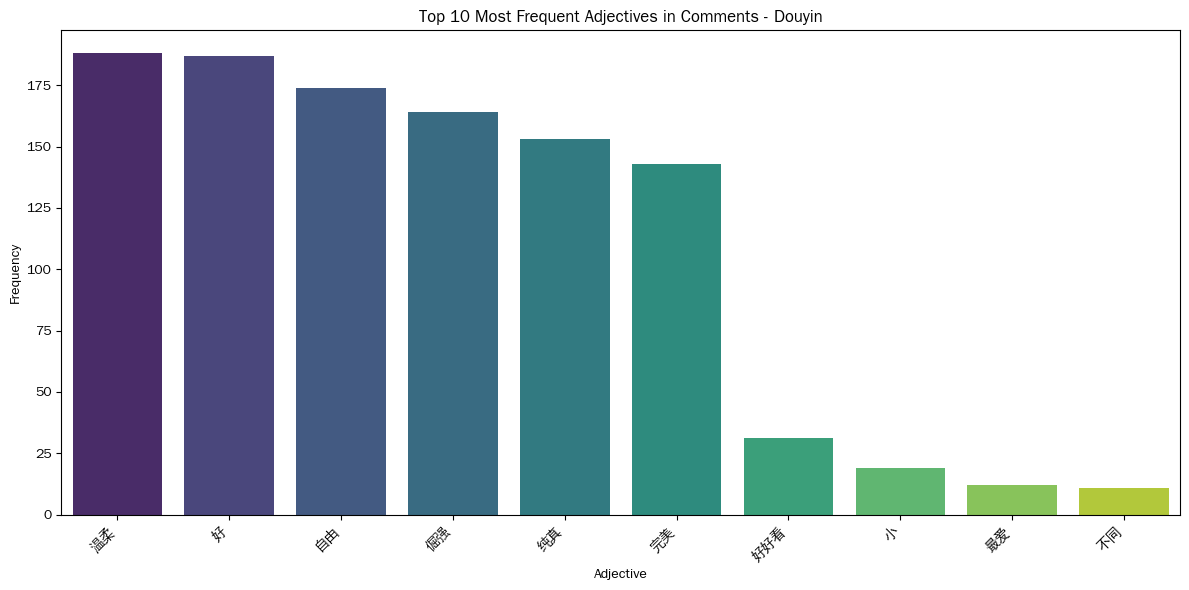

In [44]:
# Define the path to the Chinese font file
font_path = '/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc'

# Check if the font exists and configure Matplotlib to use it
if os.path.exists(font_path):
    # Add the font to Matplotlib's font manager
    fm.fontManager.addfont(font_path)
    # Set the default sans-serif font to the Chinese font
    plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']
    # Ensure negative signs are displayed correctly
    plt.rcParams['axes.unicode_minus'] = False
    print(f"Chinese font '{os.path.basename(font_path)}' configured for matplotlib.")
else:
    print(f"Warning: Chinese font not found at {font_path}. Chinese characters may not display correctly.")

# Concatenate all comments from the sentiment-filtered DataFrame into a single string
all_comments = ' '.join(df['Comment'].astype(str))

# Perform Chinese word segmentation and part-of-speech tagging on the comments
words_with_pos = pseg.cut(all_comments)

# Filter the segmented words to extract only adjectives (tagged with 'a')
adjectives = [word for word, flag in words_with_pos if 'a' in flag]

# Count the frequency of each extracted adjective
adjective_counts = pd.Series(adjectives).value_counts()

# Get the top 10 most frequent adjectives
top_10_adjectives = adjective_counts.head(10)

# Create a bar plot to visualize the top 10 adjectives
plt.figure(figsize=(12, 6))
# Use seaborn to create a bar plot, coloring bars by adjective for visual distinction
sns.barplot(x=top_10_adjectives.index, y=top_10_adjectives.values, hue=top_10_adjectives.index, palette='viridis', legend=False)
plt.title('Top 10 Most Frequent Adjectives in Comments - Douyin')
plt.xlabel('Adjective')
plt.ylabel('Frequency')
# Rotate x-axis labels for better readability if they overlap
plt.xticks(rotation=45, ha='right')
# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

### 5. Top 10 Most Frequent Adjectives

Building upon the adjective extraction, this section quantifies the frequency of each adjective and visualizes the top 10 most common ones using a bar chart.

-   **Frequency Counting:** The extracted adjectives are counted to determine their prevalence in the comments.
-   **Bar Chart Visualization:** A `seaborn` bar plot clearly displays the top 10 adjectives and their corresponding frequencies, offering a more precise view than the word cloud. This helps in identifying specific, highly recurrent keywords that describe the perceived design style.

This provides concrete insights into the attributes that users most frequently associate with the Pop Mart designs, offering valuable keywords for defining the flat design style from a market perspective.


### 6. Conclusion and Design Insights

Based on the analysis of Douyin Pop Mart comments, after cleaning and filtering for positive sentiment, the most frequently used adjectives provide valuable insights into the perceived flat design style. The top 10 adjectives identified are:

1.  **温柔 (Wēnróu - Gentle/Tender)**: 188 mentions
2.  **好 (Hǎo - Good/Nice)**: 187 mentions
3.  **自由 (Zìyóu - Free/Unrestrained)**: 174 mentions
4.  **倔强 (Juéjiàng - Stubborn/Unyielding)**: 164 mentions
5.  **纯真 (Chúnzhēn - Innocent/Pure)**: 153 mentions
6.  **完美 (Wánměi - Perfect)**: 143 mentions
7.  **好好看 (Hǎohǎokàn - Very Good-looking)**: 31 mentions
8.  **小 (Xiǎo - Small)**: 19 mentions
9.  **最爱 (Zuì'ài - Favorite)**: 12 mentions
10. **不同 (Bùtóng - Different)**: 11 mentions

These keywords suggest that users appreciate designs that are **gentle, expressive of freedom, possess a unique unyielding spirit, maintain an innocent charm, and are perceived as perfect or aesthetically pleasing**. These terms can serve as strong foundational keywords for defining and marketing the flat design style associated with Pop Mart products, highlighting the emotional and aesthetic qualities that resonate with the audience.